# About This notebook

This notebook continues the Exploratory Data Analysis from the previous notebook. 

Here, we import data from the `stage_02` schema from the PostgreSQL database `train_reward_compare`. 

This model continues through to the end of the Modeling Stage of the data pipeline.

When finished, insights from this notebook can be output in various formats to be assembled in a final presentation.

## Links to Data

[https://www.onetcenter.org/database.html#all-files](https://www.onetcenter.org/database.html#all-files)

[https://www.bls.gov/oes/](https://www.bls.gov/oes/)

# Project Setup

## Import and Verifications

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlalchemy

In [2]:
print(sqlalchemy.__version__)
print(np.__version__)

2.0.48
2.1.0


In [3]:
from sqlalchemy import create_engine, inspect
from sqlalchemy import text
from sqlalchemy.schema import CreateSchema
from sqlalchemy import BigInteger, Column, Integer, String, Float, Boolean, Text, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

In [4]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

## Create SQL Engine and Test Connection

In [5]:
engine = create_engine('postgresql+psycopg2://postgres@localhost/train_reward_compare')

In [6]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from onet.occupation_data"))
    print(result.fetchone())

(1016,)


# Import Data from PostgreSQL

## List of Imports

We start by bringing the previous dataset stored in the `stage_02` schema.

- df

## Import Dataset

In [7]:
# Data Schema for Import
schema_name_import = 'stage_02'

# Data Table Names
df_table_name = 'df'

In [8]:
full_df = pd.DataFrame()

with engine.connect() as conn:
    df = pd.read_sql_table(df_table_name, schema=schema_name_import, con=engine, index_col='id')

In [9]:
df.head()

,onetsoc_code,education_sum,occ_code,accepted_title,a_mean
id,,,,,
1,29-1221,1177.03,29-1221,"Pediatricians, General",222340.0
2,29-1218,1170.56,29-1218,Obstetricians and Gynecologists,281130.0
3,29-1022,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0
4,29-1211,1160.55,29-1211,Anesthesiologists,336640.0
5,29-1214,1158.62,29-1214,Emergency Medicine Physicians,320700.0


# Prepping Data

## Dropping `onetsoc_code`

We've come now to the stage where we need to prepare to create dummy columns.

The primary categories that we wish to observe are the `major` and `minor` groups. Those are determined respectively by the first two digits and the first four digits (excluding the hyphen) of the associated code.

We've kept both the O*NET code and the BLS code up to this point.

The differences between these two columns are limited strictly to the minutiae of the `broad` and `detailed` subgroups, which are not within the scope of our categories.

Therefore, we'll drop the `onetsoc_code` from the O*NET dataset and keep only `occ_code'.

In [10]:
df = df.drop(columns=['onetsoc_code'])

## Creating Dummy Variables

Let's create two new columns: one for the `major` categories and one for the `minor` categories.

In [11]:
df['major'] = df['occ_code'].str[:2]

In [12]:
df['minor'] = df['occ_code'].str[:5]

In [13]:
df.head()

,education_sum,occ_code,accepted_title,a_mean,major,minor
id,,,,,,
1,1177.03,29-1221,"Pediatricians, General",222340.0,29,29-12
2,1170.56,29-1218,Obstetricians and Gynecologists,281130.0,29,29-12
3,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0,29,29-10
4,1160.55,29-1211,Anesthesiologists,336640.0,29,29-12
5,1158.62,29-1214,Emergency Medicine Physicians,320700.0,29,29-12


Let's perform one-hot encoding by creating dummy variables. 

In [14]:
df_d = pd.get_dummies(df, columns=['major', 'minor'], prefix='c')

In [15]:
df_d.columns = df_d.columns.astype(str)

In [16]:
df_d.head()

,education_sum,occ_code,accepted_title,a_mean,c_11,c_13,c_15,c_17,c_19,c_21,...,c_51-90,c_51-91,c_53-10,c_53-20,c_53-30,c_53-40,c_53-50,c_53-60,c_53-70,c_53-71
id,,,,,,,,,,,,,,,,,,,,,
1,1177.03,29-1221,"Pediatricians, General",222340.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1170.56,29-1218,Obstetricians and Gynecologists,281130.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1160.55,29-1211,Anesthesiologists,336640.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1158.62,29-1214,Emergency Medicine Physicians,320700.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Train, Test, Split

As noted above, there is a positive linear relationship between the two variables, `education_sum` and `a_mean`.

We now divide the data into training and test sets and create a prediction model.

In [17]:
X = pd.DataFrame(df_d.drop(columns=['a_mean', 'accepted_title', 'occ_code']))
y = pd.DataFrame(df_d['a_mean'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(547, 132)
(183, 132)
(547, 1)
(183, 1)


## Implementing a Scalar

In [20]:
scaler = StandardScaler()

In [21]:
scaler.fit(X_train[['education_sum']])

,copy,True
,with_mean,True
,with_std,True


In [22]:
X_train['scaled_ed_sum'] = scaler.transform(X_train[['education_sum']])

In [23]:
X_test['scaled_ed_sum'] = scaler.transform(X_test[['education_sum']])

# Modeling

Our dataframes and scaler are prepared, and therefore we are ready to do our modeling.

## Linear Regression Model

### Make the Linear Regression Model

In [24]:
rModel = linear_model.LinearRegression()

In [25]:
# I was getting an error message about needing to rename columns to strings
# Got help from stackoverflow to avoid the issue
X_train = X_train.rename(str,axis="columns")
X_test = X_test.rename(str,axis="columns")
y_train = y_train.rename(str,axis="columns")
y_test = y_test.rename(str,axis="columns")

In [26]:
rModel.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Evaluate the Model

In [27]:
y_pred = rModel.predict(X_train)

In [28]:
r2 = r2_score(y_train, y_pred)

In [29]:
print(r2)

0.7950433603653975


At the moment, our model explains 79.5% of the variation.

### Refining the Model

Let's continue refining.

In [32]:
y_pred.shape

(547, 1)

#### Plot the Predictions vs the Actual

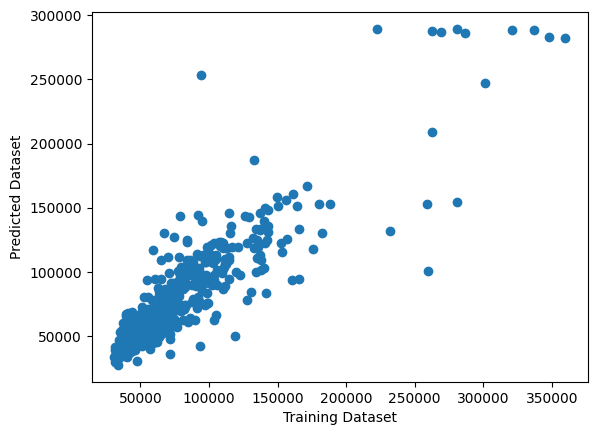

In [33]:
_ = plt.scatter(x=y_train, y=y_pred)
_ = plt.xlabel('Training Dataset')
_ = plt.ylabel('Predicted Dataset')
plt.show()

There is a visible positive correlation, but there is room for improvement.

## Ordinary Least Squares Model

We try another type of regression model: Ordinary Least Squares.

### Set Up the Data

In [51]:
X_ols = pd.DataFrame(df_d.drop(columns=['a_mean', 'accepted_title', 'occ_code']).astype(float))
X_ols = sm.add_constant(X_ols)

In [52]:
y_ols = pd.DataFrame(df_d[['a_mean']])

In [53]:
X_ols_train, X_ols_test, y_ols_train, y_ols_test = train_test_split(X_ols, y_ols, test_size=0.25, random_state=42)

### Train the Model

In [54]:
y_ols_train['a_mean'].dtype

dtype('float64')

In [55]:
rModel_ols = sm.OLS(y_ols_train, X_ols_train).fit()

### Evaluate the Model

In [56]:
rModel_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 a_mean   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.746
Method:                 Least Squares   F-statistic:                     16.29
Date:                Tue, 16 Jun 2026   Prob (F-statistic):          1.70e-101
Time:                        21:26:53   Log-Likelihood:                -6228.2
No. Observations:                 547   AIC:                         1.267e+04
Df Residuals:                     441   BIC:                         1.312e+04
Df Model:                         105                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          4.694e+04   3363.248     13.958      0.000    4.03e+04    5.36e+04
education_sum    60.8095      7.771      7.825      0.000      45.537      76.082
c_11           5.565e+04   5099.977     10.912      0.000    4.56e+04    6.57e+04
c_13           9172.9995   4620.483      1.985      0.048      92.097    1.83e+04
c_15           2.128e+04   5213.467      4.082      0.000     1.1e+04    3.15e+04
c_17           1.694e+04   4443.995      3.812      0.000    8207.471    2.57e+04
c_19           1335.0973   4776.119      0.280      0.780   -8051.685    1.07e+04
c_21          -8836.7935   8229.415     -1.074      0.283    -2.5e+04    7336.951
c_23           3875.5957   6794.911      0.570      0.569   -9478.836    1.72e+04
c_25           -1.44e+04   4473.151     -3.218      0.001   -2.32e+04   -5604.776
c_27           3082.1239   4677.574      0.659      0.510   -6110.983    1.23e+04
c_29            3.52e+04   4456.326      7.900      0.000    2.64e+04     4.4e+04
c_31          -1.556e+04   4984.587     -3.121      0.002   -2.54e+04   -5761.887
c_33           2558.0113   6320.041      0.405      0.686   -9863.130     1.5e+04
c_35          -1.783e+04   6679.044     -2.670      0.008    -3.1e+04   -4703.661
c_37          -1.193e+04   7792.312     -1.531      0.127   -2.72e+04    3388.370
c_39          -1.731e+04   5643.492     -3.067      0.002   -2.84e+04   -6215.295
c_41           8562.8634   5785.409      1.480      0.140   -2807.535    1.99e+04
c_43          -1.567e+04   4532.383     -3.458      0.001   -2.46e+04   -6764.438
c_45          -1.307e+04   5699.907     -2.293      0.022   -2.43e+04   -1869.185
c_47            -12.5051   3761.684     -0.003      0.997   -7405.560    7380.550
c_49            289.5370   3207.898      0.090      0.928   -6015.131    6594.205
c_51          -7444.6310   3504.433     -2.124      0.034   -1.43e+04    -557.166
c_53           1.105e+04   4788.794      2.307      0.021    1637.903    2.05e+04
c_11-10        6.225e+04   1.51e+04      4.127      0.000    3.26e+04    9.19e+04
c_11-20        2.385e+04   1.13e+04      2.114      0.035    1678.691     4.6e+04
c_11-30        1.666e+04   9681.356      1.721      0.086   -2362.359    3.57e+04
c_11-31        1.483e+04   2.07e+04      0.716      0.474   -2.59e+04    5.55e+04
c_11-90       -3.043e+04   8774.559     -3.468      0.001   -4.77e+04   -1.32e+04
c_11-91       -3.151e+04   1.13e+04     -2.794      0.005   -5.37e+04   -9348.956
c_13-10        9383.1525   8255.410      1.137      0.256   -6841.682    2.56e+04
c_13-11        -150.6421   1.07e+04     -0.014      0.989   -2.13e+04     2.1e+04
c_13-20         -59.5108   7044.294     -0.008      0.993   -1.39e+04    1.38e+04
c_15-12        1.873e+04   6829.474      2.743      0.006    5310.939    3.22e+04
c_15-20        2545.8002   9544.248      0.267   

#### Commentary

The condition number is extremely large at 8.91e+18. This is a sign of severe multicolinearity.

The r-squared value is the same as before, 79.5%.

Because of the high condition number, the OLS method does not provide a usable model.

### Use the Model to Make Predictions

In [57]:
y_test_pred = rModel.predict(X_test)

In [61]:
r2_test = r2_score(y_test, y_test_pred)

In [64]:
y_test_pred.shape

(183, 1)

### Plot Predictions

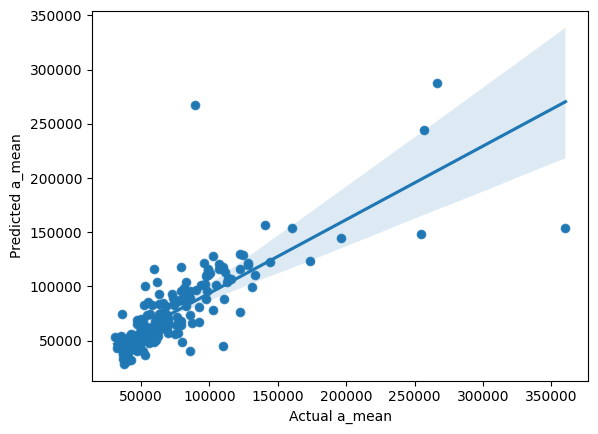

In [67]:
_ = sns.scatterplot(x=y_test['a_mean'], y=y_test_pred.flatten())
_ = sns.regplot(x=y_test['a_mean'], y=y_test_pred.flatten())
_.set(xlabel='Actual a_mean', ylabel='Predicted a_mean')
plt.show()

At an R^2 value of 0.795, we seem to have found some value in the model.

# Conclusions

There is a positive correlation between the value respondents place on higher levels of education and an increase in average annual salary.

However, while the linear-regression model is useful, there is not a definitive correlation.

This is logical, because some careers require skills that are difficult to teach, if not impossible. For example, CEOs require more than just mathematical learning; they require leadership, which is a truly difficult concept to translate into a classroom curriculum.

Another example can be found with sports athletes. Professional athletes make exorbant amounts of income, but may not need an education beyond high school.

Therefore, education does seem to have value overall, but it is not an ultimate factor in an individual person's earning potential.